# INITIAL_SETUP - USE CPU MODE FOR THIS!!

In [1]:
import os
import json
import pandas as pd
from tqdm import tqdm
from typing import List, Optional
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import torch
from IPython.display import FileLink
import seaborn as sns
import matplotlib.pyplot as plt
import cv2
import matplotlib.patches as patches
import shutil
import skimage
from PIL import Image, ImageDraw
print(cv2.cuda.getCudaEnabledDeviceCount())
tqdm.pandas()
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

0


2026-03-21 03:40:16.602753: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774064416.940770      25 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774064417.034540      25 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774064417.868502      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774064417.868540      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774064417.868542      25 computation_placer.cc:177] computation placer alr

In [2]:
%%bash
sed 's|/content/train/image/|/kaggle/input/datasets/ar3snd/deepfashion-dataset/dataset/backup/train/image/|g' /kaggle/input/datasets/ar3snd/deepfashion-dataset/combined_train.csv > combined_train.csv
sed 's|/content/validation/image/|/kaggle/input/datasets/ar3snd/deepfashion-dataset/dataset/backup/validation/image/|g' /kaggle/input/datasets/ar3snd/deepfashion-dataset/combined_validation.csv > combined_validation.csv

In [3]:
train_df = pd.read_csv("combined_train.csv")
validation_df = pd.read_csv("combined_validation.csv")

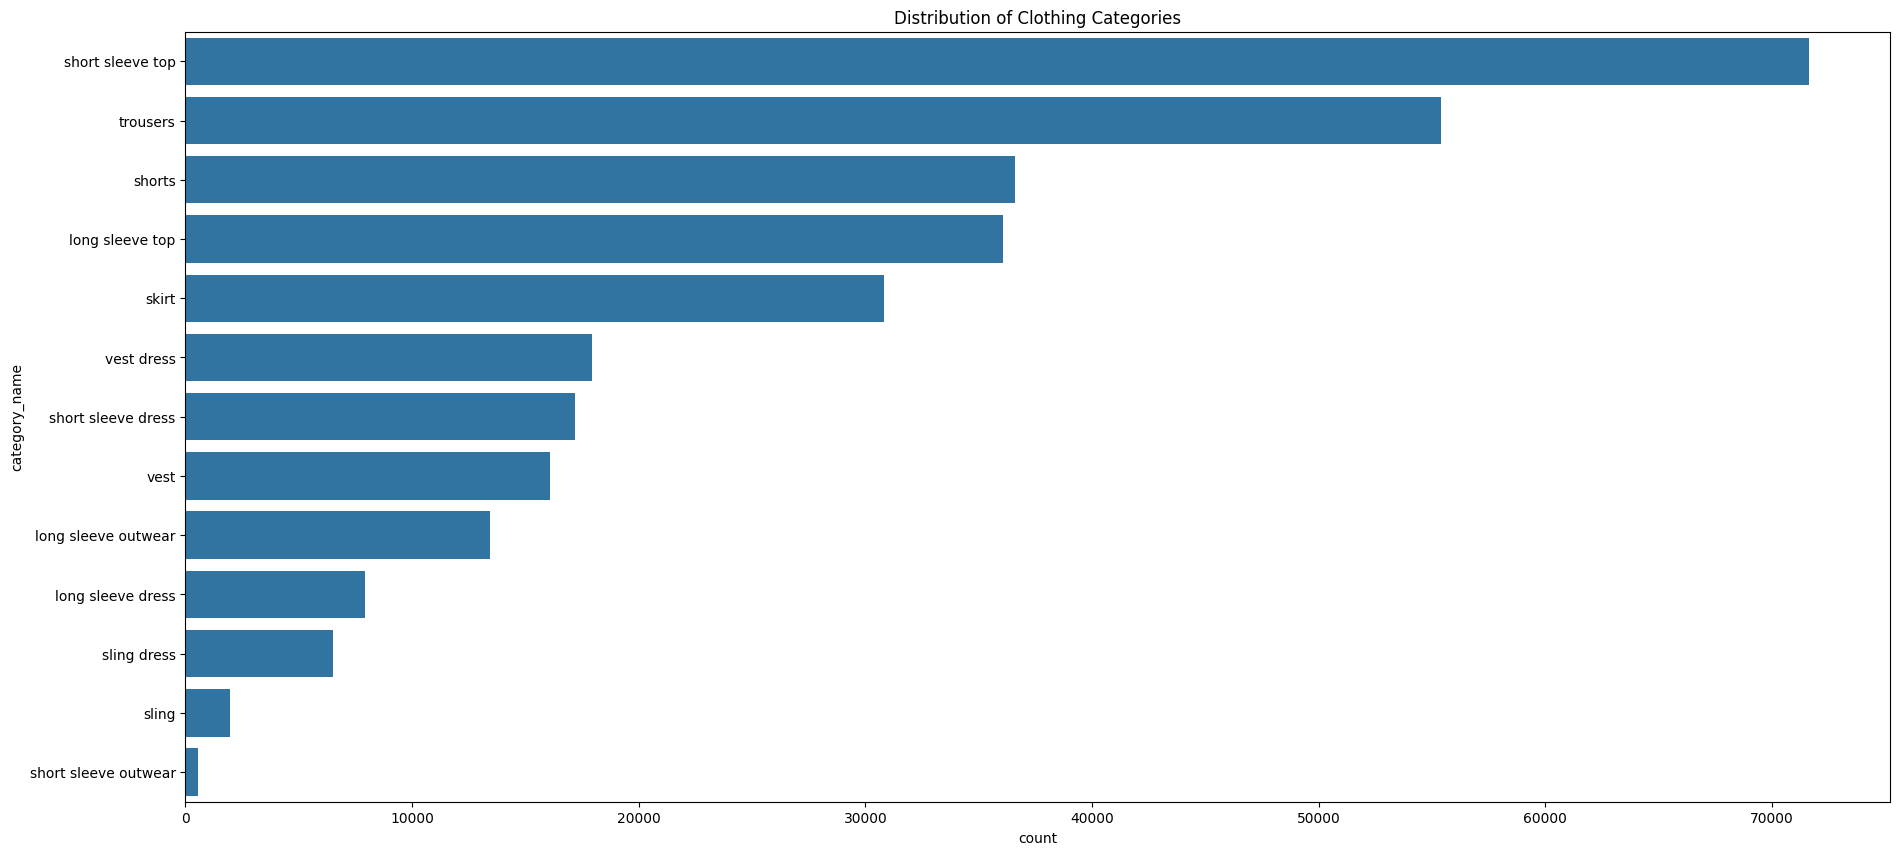

In [4]:
fig, ax = plt.subplots(figsize=(22,10))
sns.countplot(y='category_name', data=train_df, order=train_df['category_name'].value_counts().index)
plt.title('Distribution of Clothing Categories')
plt.show()

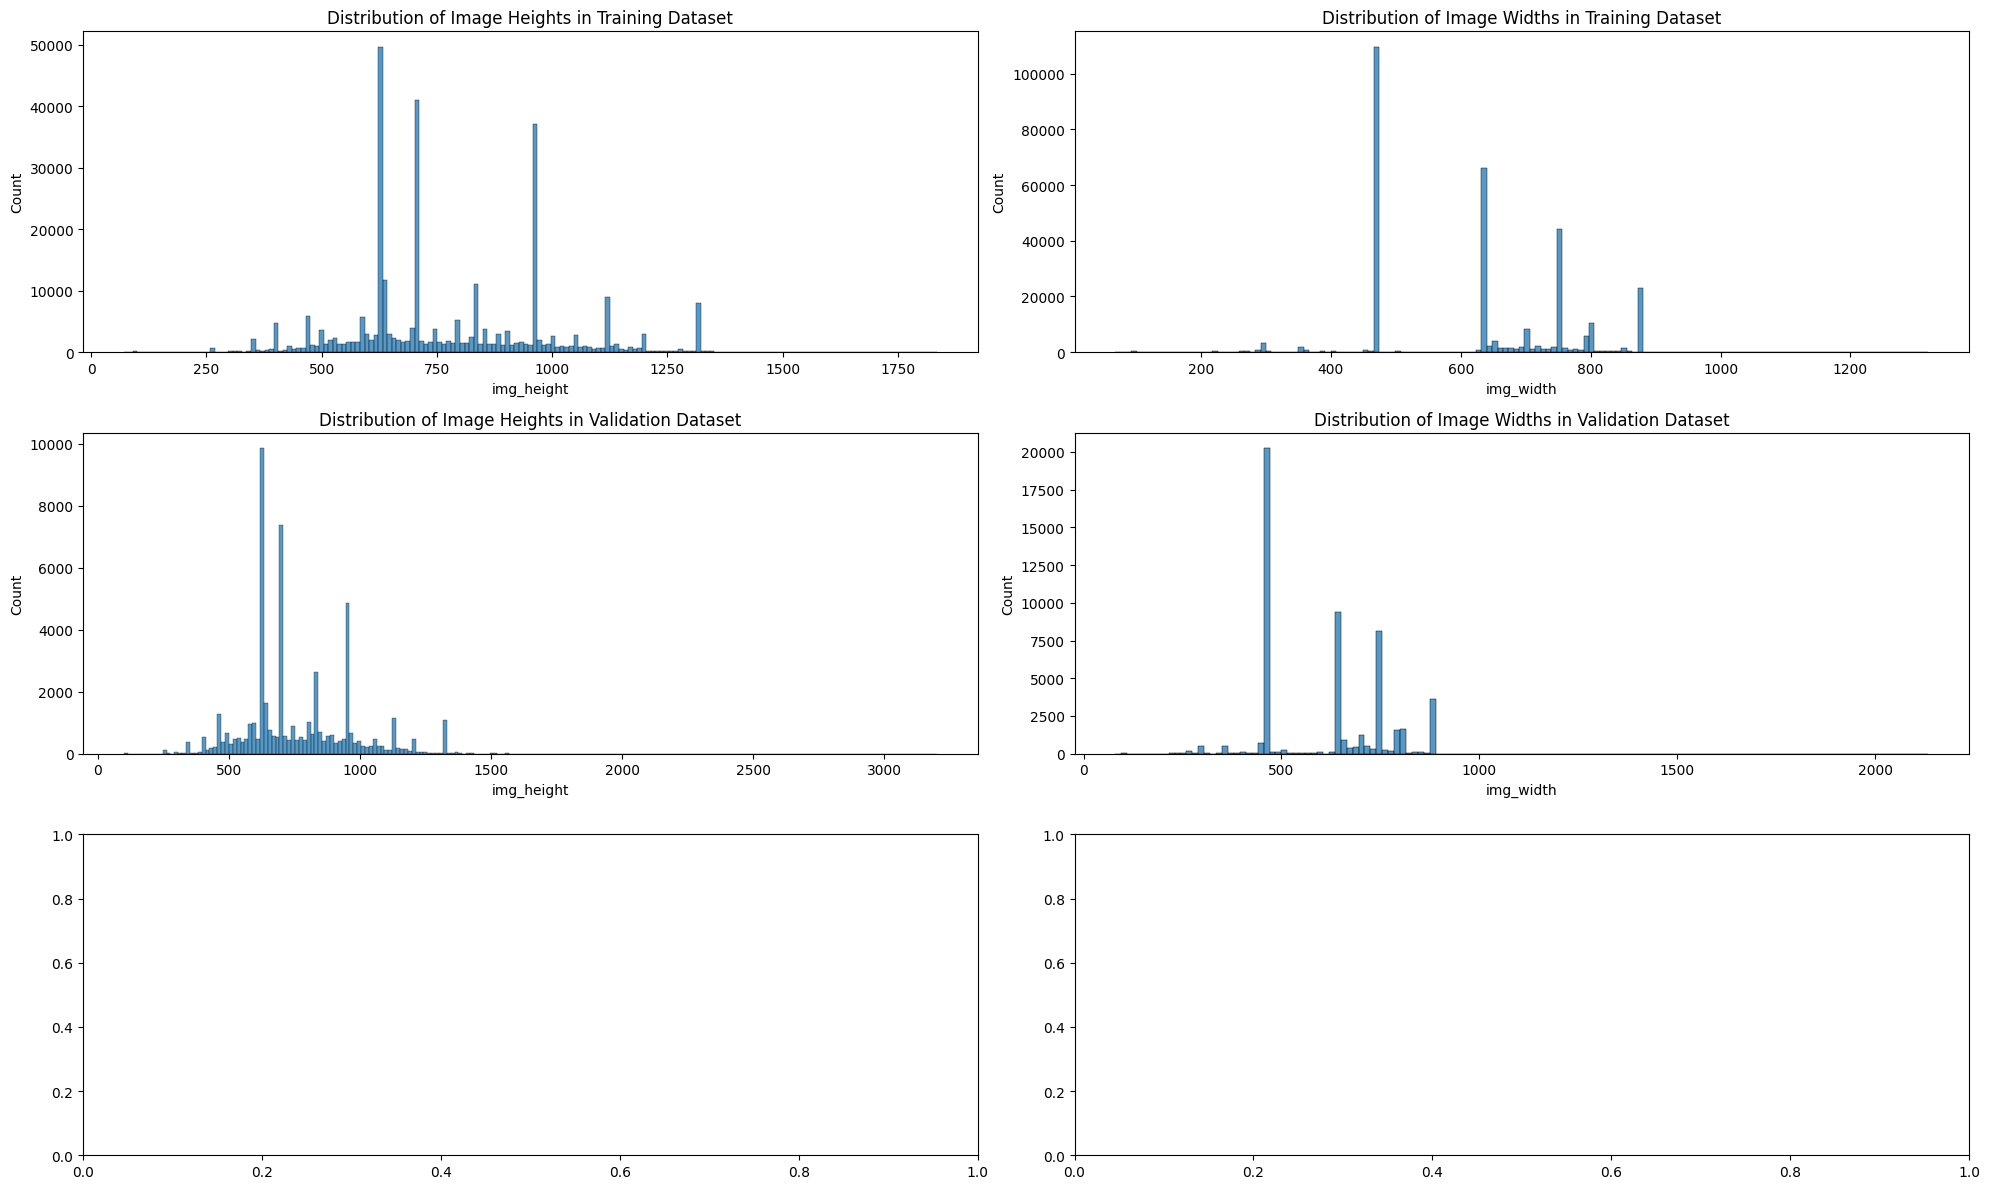

In [5]:
fig, ax = plt.subplots(3, 2, figsize=(20,12))
sns.histplot(train_df['img_height'], ax=ax[0, 0]).set_title('Distribution of Image Heights in Training Dataset')
sns.histplot(train_df['img_width'], ax=ax[0, 1]).set_title('Distribution of Image Widths in Training Dataset')

sns.histplot(validation_df['img_height'], ax=ax[1, 0]).set_title('Distribution of Image Heights in Validation Dataset')
sns.histplot(validation_df['img_width'], ax=ax[1, 1]).set_title('Distribution of Image Widths in Validation Dataset')

# sns.histplot(test_df['img_height'], ax=ax[2, 0]).set_title('Distribution of Image Heights in Test Dataset')
# sns.histplot(test_df['img_width'], ax=ax[2, 1]).set_title('Distribution of Image Widths in Test Dataset')

plt.tight_layout()
plt.show()

In [6]:
TOP_CATEGORIES = {
    "short sleeve top",
    "trousers",
    "shorts",
    "long sleeve top",
    "skirt"
}
filtered_df = train_df[train_df["category_name"].isin(TOP_CATEGORIES)]
keep_images = set(filtered_df["path"].apply(os.path.basename))

In [7]:
# import os
# from tqdm import tqdm
# import subprocess

# def folder_size(path):
#     result = subprocess.check_output(['du','-sh',path]).split()[0].decode('utf-8')
#     return result

In [8]:
# import os, shutil
# from tqdm import tqdm

# src_dir = "/kaggle/input/datasets/ar3snd/deepfashion-dataset/dataset/backup/train/image"
# dst_dir = "/kaggle/temp/train"

# os.makedirs(dst_dir, exist_ok=True)

# for img in tqdm(keep_images):
#     src = os.path.join(src_dir, img)
#     dst = os.path.join(dst_dir, img)

#     if os.path.exists(src):
#         shutil.copy(src, dst)

In [9]:
# filtered_df = validation_df[validation_df["category_name"].isin(TOP_CATEGORIES)]
# keep_images = set(filtered_df["path"].apply(os.path.basename))

In [10]:
# import os, shutil
# from tqdm import tqdm

# src_dir = "/kaggle/input/datasets/ar3snd/deepfashion-dataset/dataset/backup/validation/image"
# dst_dir = "/kaggle/temp/validation"

# os.makedirs(dst_dir, exist_ok=True)

# for img in tqdm(keep_images):
#     src = os.path.join(src_dir, img)
#     dst = os.path.join(dst_dir, img)

#     if os.path.exists(src):
#         shutil.copy(src, dst)

In [11]:
# image_dir = "/kaggle/input/datasets/ar3snd/deepfashion-dataset/dataset/backup/validation/image"
# print("Before:", folder_size(image_dir))
# for img in tqdm(os.listdir(image_dir)):
#     if img not in keep_images:
#         os.remove(os.path.join(image_dir, img))
# print("After:", folder_size(image_dir))

In [12]:
# %%bash
# zip -r /kaggle/working/dataset_train.zip /kaggle/input/datasets/ar3snd/deepfashion-dataset/dataset/backup/train/image
# zip -r /kaggle/working/dataset_validation.zip /kaggle/input/datasets/ar3snd/deepfashion-dataset/dataset/backup/validation/image

In [13]:
# %%capture
# %%bash

# DATASET_PATH="/kaggle/working/"
# PASSWORD=""
# EXTRACT_TO="/kaggle/temp/"

# echo "Searching for zip files in: $DATASET_PATH"

# for file in "$DATASET_PATH"/*.zip; do
#     if [ -f "$file" ]; then
#         echo "Extracting: $file"
#         unzip -P "$PASSWORD" -o "$file" -d "$EXTRACT_TO"
#         echo "Finished: $file"
#     fi
# done

# echo "Extraction complete."

In [14]:
# %%bash
# sed -i 's|/content/train/image/|/kaggle/temp/train/|g' combined_train.csv 
# sed -i 's|/content/validation/image/|/kaggle/temp/validation/|g' combined_validation.csv

In [15]:
# train_df = pd.read_csv("combined_train.csv")
# validation_df = pd.read_csv("combined_validation.csv")
# # test_df = pd.read_csv("combined_test.csv")

In [16]:
train_df.head()

,path,segmentation,landmarks,b_box,category_id,category_name,scale,viewpoint,occlusion,zoom_in,img_height,img_width
0,/kaggle/input/datasets/ar3snd/deepfashion-data...,"[[357, 460, 309, 464, 256, 465, 270, 589, 289,...","[256, 465, 1, 309, 464, 1, 357, 460, 1, 270, 5...","[241, 447, 378, 718]",8,trousers,1,2,2,2,719,640
1,/kaggle/input/datasets/ar3snd/deepfashion-data...,"[[298, 196, 286, 181, 275, 167, 257, 187, 223,...","[296, 168, 1, 275, 167, 2, 286, 181, 2, 298, 1...","[187, 163, 389, 622]",4,long sleeve outwear,2,3,2,1,719,640
2,/kaggle/input/datasets/ar3snd/deepfashion-data...,"[[584, 390, 513, 396, 439, 400, 439, 471, 448,...","[439, 400, 1, 513, 396, 1, 584, 390, 1, 439, 4...","[432, 385, 620, 537]",7,shorts,1,2,2,1,581,880
3,/kaggle/input/datasets/ar3snd/deepfashion-data...,"[[408, 232, 432, 259, 473, 267, 504, 240, 501,...","[460, 236, 1, 408, 232, 1, 432, 259, 2, 473, 2...","[382, 195, 595, 457]",5,vest,2,2,2,1,581,880
4,/kaggle/input/datasets/ar3snd/deepfashion-data...,"[[327, 469, 364, 457, 394, 442, 434, 503, 460,...","[394, 442, 1, 364, 457, 1, 327, 469, 1, 434, 5...","[326, 440, 467, 622]",8,trousers,1,3,2,2,623,468


In [17]:
validation_df.head()

,path,segmentation,landmarks,b_box,category_id,category_name,scale,viewpoint,occlusion,zoom_in,img_height,img_width
0,/kaggle/input/datasets/ar3snd/deepfashion-data...,"[[88.89710806697141, 344.87755792322196, 66.36...","[89, 346, 1, 152, 394, 1, 261, 407, 1, 21, 433...","[5, 346, 270, 664]",7,shorts,2,2,2,1,702,468
1,/kaggle/input/datasets/ar3snd/deepfashion-data...,"[[226.8830127213216, 3.37095108562864, 219.273...","[277, 6, 1, 222, 4, 2, 219, 24, 2, 250, 26, 2,...","[73, 5, 427, 435]",1,short sleeve top,3,2,1,1,702,468
2,/kaggle/input/datasets/ar3snd/deepfashion-data...,"[[223.65714285714287, 0.2666666666666657, 159....","[0, 0, 0, 235, 69, 2, 256, 146, 2, 276, 176, 2...","[121, 0, 355, 623]",13,sling dress,3,1,1,2,624,468
3,/kaggle/input/datasets/ar3snd/deepfashion-data...,"[[29.314285714285713, 81.77142857142857, 31.62...","[28, 85, 1, 239, 98, 2, 437, 90, 1, 36, 347, 2...","[5, 81, 467, 628]",7,shorts,3,2,1,1,702,468
4,/kaggle/input/datasets/ar3snd/deepfashion-data...,"[[35.71883454734651, 0.0, 33.8207819235915, 11...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[13, 0, 450, 115]",1,short sleeve top,2,2,1,2,702,468


In [18]:
# PURGE USELESS CATEGORIES
TOP_CATEGORIES = {
    "short sleeve top",
    "trousers",
    "shorts",
    "long sleeve top",
    "skirt"
}
train_df = train_df[train_df["category_name"].isin(TOP_CATEGORIES)]
validation_df = validation_df[validation_df["category_name"].isin(TOP_CATEGORIES)]

In [19]:
import os
RESIZED_TARGET_DIRECTORY = "/kaggle/temp/resized/"
# TARGET_DIR = "/content/"
TARGET_SIZE = (224, 224)
os.makedirs(os.path.join(RESIZED_TARGET_DIRECTORY, "train"))
os.makedirs(os.path.join(RESIZED_TARGET_DIRECTORY, "validation"))
os.makedirs(os.path.join(RESIZED_TARGET_DIRECTORY, "test"))
# os.makedirs(TARGET_DIR)

In [20]:
import ast

train_df["b_box"] = train_df["b_box"].apply(ast.literal_eval)
train_df["segmentation"] = train_df["segmentation"].apply(ast.literal_eval)
train_df["landmarks"] = train_df["landmarks"].apply(ast.literal_eval)
validation_df["b_box"] = validation_df["b_box"].apply(ast.literal_eval)
validation_df["segmentation"] = validation_df["segmentation"].apply(ast.literal_eval)
validation_df["landmarks"] = validation_df["landmarks"].apply(ast.literal_eval)

In [21]:
def resize_bbox(bbox, x_scale, y_scale):
    return [bbox[0] * x_scale,
            bbox[1] * y_scale,
            bbox[2] * x_scale,
            bbox[3] * y_scale]

def resize_segmentation(segmentation, x_scale, y_scale):
    resized_segmentation = []
    for polygon in segmentation:
        resized_polygon = []
        for i in range(0, len(polygon), 2):
            x = polygon[i] * x_scale
            y = polygon[i + 1] * y_scale
            resized_polygon.extend([x, y])
        resized_segmentation.append(resized_polygon)

    return resized_segmentation

def resize_image_and_annotations(row,skip=True):
    # Creating path for the resized image
    # sample original path -> /kaggle/input/deepfashion2-original-with-dataframes/DeepFashion2/deepfashion2_original_images/train/image/000001.jpg
    img_path = row['path']
    name_list = img_path.split("/")
    df_type = name_list[-3]
    new_img_path = os.path.join(RESIZED_TARGET_DIRECTORY, df_type, name_list[-1])
    if skip:
        row['path'] = new_img_path
        row['img_height'] = TARGET_SIZE[1]
        row['img_width'] = TARGET_SIZE[0]
        row['b_box'] = {}
        row['segmentation'] = {}
        return row
    new_image = cv2.imread(new_img_path) if os.path.exists(new_img_path) else None
            

    # Reading & resizing the image; saving resized image into new folder
    image = cv2.imread(img_path)
    original_height, original_width = image.shape[:2]
    # early backout if already exists!
    if new_image is not None and new_image.shape[:2] == (TARGET_SIZE[1], TARGET_SIZE[0]):
        1+1
    else:
        resized_image = cv2.resize(image, TARGET_SIZE, interpolation=cv2.INTER_AREA)
        cv2.imwrite(new_img_path, resized_image)

    if df_type == "test":
        # Update the dataframe row
        row['path'] = new_img_path
        row['img_height'] = TARGET_SIZE[1]
        row['img_width'] = TARGET_SIZE[0]
    else:
        bbox = row['b_box']
        segmentation = row['segmentation']

        # Calculate the scaling factors
        x_scale = TARGET_SIZE[0] / original_width
        y_scale = TARGET_SIZE[1] / original_height

        # Resize the bounding box
        resized_bbox = resize_bbox(bbox, x_scale, y_scale)

        # Resize the segmentation
        resized_segmentation = resize_segmentation(segmentation, x_scale, y_scale)

        # Update the dataframe row
        row['path'] = new_img_path
        row['b_box'] = resized_bbox
        row['segmentation'] = resized_segmentation
        row['img_height'] = TARGET_SIZE[1]
        row['img_width'] = TARGET_SIZE[0]

    return row

In [22]:
%%bash
%%capture
unzip "/kaggle/input/datasets/ar3snd/deepfashion-dataset/dataset_resized.zipx" -d '/' > /dev/null 2>&1

bash: line 1: fg: no job control


In [23]:
print(train_df.dtypes)
print("\n\n")
print(validation_df.dtypes)

path             object
segmentation     object
landmarks        object
b_box            object
category_id       int64
category_name    object
scale             int64
viewpoint         int64
occlusion         int64
zoom_in           int64
img_height        int64
img_width         int64
dtype: object



path             object
segmentation     object
landmarks        object
b_box            object
category_id       int64
category_name    object
scale             int64
viewpoint         int64
occlusion         int64
zoom_in           int64
img_height        int64
img_width         int64
dtype: object


In [24]:
train_df_resized = train_df.progress_apply(resize_image_and_annotations, axis=1)
validation_df_resized = validation_df.progress_apply(resize_image_and_annotations, axis=1)

100%|██████████| 38797/38797 [00:02<00:00, 14121.98it/s]


In [25]:
train_df_resized.head()

,path,segmentation,landmarks,b_box,category_id,category_name,scale,viewpoint,occlusion,zoom_in,img_height,img_width
0,/kaggle/temp/resized/train/140381.jpg,{},"[256, 465, 1, 309, 464, 1, 357, 460, 1, 270, 5...",{},8,trousers,1,2,2,2,224,224
2,/kaggle/temp/resized/train/085839.jpg,{},"[439, 400, 1, 513, 396, 1, 584, 390, 1, 439, 4...",{},7,shorts,1,2,2,1,224,224
4,/kaggle/temp/resized/train/101865.jpg,{},"[394, 442, 1, 364, 457, 1, 327, 469, 1, 434, 5...",{},8,trousers,1,3,2,2,224,224
6,/kaggle/temp/resized/train/007648.jpg,{},"[511, 342, 1, 474, 363, 1, 420, 371, 1, 547, 4...",{},9,skirt,1,3,3,1,224,224
7,/kaggle/temp/resized/train/007648.jpg,{},"[497, 199, 2, 498, 193, 2, 0, 0, 0, 0, 0, 0, 0...",{},1,short sleeve top,1,3,1,1,224,224


In [26]:
train_df_resized.to_csv('train_df_224.csv')
validation_df_resized.to_csv('validation_df_224.csv')

In [27]:
train_df.head()

,path,segmentation,landmarks,b_box,category_id,category_name,scale,viewpoint,occlusion,zoom_in,img_height,img_width
0,/kaggle/input/datasets/ar3snd/deepfashion-data...,"[[357, 460, 309, 464, 256, 465, 270, 589, 289,...","[256, 465, 1, 309, 464, 1, 357, 460, 1, 270, 5...","[241, 447, 378, 718]",8,trousers,1,2,2,2,719,640
2,/kaggle/input/datasets/ar3snd/deepfashion-data...,"[[584, 390, 513, 396, 439, 400, 439, 471, 448,...","[439, 400, 1, 513, 396, 1, 584, 390, 1, 439, 4...","[432, 385, 620, 537]",7,shorts,1,2,2,1,581,880
4,/kaggle/input/datasets/ar3snd/deepfashion-data...,"[[327, 469, 364, 457, 394, 442, 434, 503, 460,...","[394, 442, 1, 364, 457, 1, 327, 469, 1, 434, 5...","[326, 440, 467, 622]",8,trousers,1,3,2,2,623,468
6,/kaggle/input/datasets/ar3snd/deepfashion-data...,"[[511, 342, 474, 363, 420, 371, 418, 457, 413,...","[511, 342, 1, 474, 363, 1, 420, 371, 1, 547, 4...","[399, 332, 577, 575]",9,skirt,1,3,3,1,587,880
7,/kaggle/input/datasets/ar3snd/deepfashion-data...,"[[459, 195, 498, 193, 527, 254, 529, 306, 512,...","[497, 199, 2, 498, 193, 2, 0, 0, 0, 0, 0, 0, 0...","[390, 179, 537, 385]",1,short sleeve top,1,3,1,1,587,880


In [28]:
validation_df.head()

,path,segmentation,landmarks,b_box,category_id,category_name,scale,viewpoint,occlusion,zoom_in,img_height,img_width
0,/kaggle/input/datasets/ar3snd/deepfashion-data...,"[[88.89710806697141, 344.87755792322196, 66.36...","[89, 346, 1, 152, 394, 1, 261, 407, 1, 21, 433...","[5, 346, 270, 664]",7,shorts,2,2,2,1,702,468
1,/kaggle/input/datasets/ar3snd/deepfashion-data...,"[[226.8830127213216, 3.37095108562864, 219.273...","[277, 6, 1, 222, 4, 2, 219, 24, 2, 250, 26, 2,...","[73, 5, 427, 435]",1,short sleeve top,3,2,1,1,702,468
3,/kaggle/input/datasets/ar3snd/deepfashion-data...,"[[29.314285714285713, 81.77142857142857, 31.62...","[28, 85, 1, 239, 98, 2, 437, 90, 1, 36, 347, 2...","[5, 81, 467, 628]",7,shorts,3,2,1,1,702,468
4,/kaggle/input/datasets/ar3snd/deepfashion-data...,"[[35.71883454734651, 0.0, 33.8207819235915, 11...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[13, 0, 450, 115]",1,short sleeve top,2,2,1,2,702,468
6,/kaggle/input/datasets/ar3snd/deepfashion-data...,"[[225.11063627730292, 22.977275810609143, 247....","[271, 13, 1, 225, 23, 1, 251, 40, 1, 291, 48, ...","[164, 8, 549, 258]",2,long sleeve top,2,2,2,2,415,663


In [29]:
# # %%capture
# !zip -r dataset_resized.zip /kaggle/temp/resized/

In [30]:
%%bash
sed -i 's|/kaggle/temp/resized/temp/|/kaggle/temp/resized/train/|g' train_df_224.csv 
sed -i 's|/kaggle/temp/resized/temp/|/kaggle/temp/resized/validation/|g' validation_df_224.csv

# START HERE - AFTER SETTING EVERYTHING UP PREVIOUSLY
# NOW USE GPU!!!!

In [31]:
# LOAD DATAFRAMES!
train_df = pd.read_csv("train_df_224.csv")
validation_df = pd.read_csv("validation_df_224.csv")

In [32]:
# %%bash
# ls -all /kaggle/temp/
# # rm -r /kaggle/temp/kaggle/temp/resized
# unzip "/kaggle/input/datasets/ar3snd/deepfashion-dataset/dataset_resized.zipx" -d '/' > /dev/null 2>&1

In [33]:
train_df.head()
validation_df.head()

,Unnamed: 0,path,segmentation,landmarks,b_box,category_id,category_name,scale,viewpoint,occlusion,zoom_in,img_height,img_width
0,0,/kaggle/temp/resized/validation/007648.jpg,{},"[89, 346, 1, 152, 394, 1, 261, 407, 1, 21, 433...",{},7,shorts,2,2,2,1,224,224
1,1,/kaggle/temp/resized/validation/007648.jpg,{},"[277, 6, 1, 222, 4, 2, 219, 24, 2, 250, 26, 2,...",{},1,short sleeve top,3,2,1,1,224,224
2,3,/kaggle/temp/resized/validation/021253.jpg,{},"[28, 85, 1, 239, 98, 2, 437, 90, 1, 36, 347, 2...",{},7,shorts,3,2,1,1,224,224
3,4,/kaggle/temp/resized/validation/021253.jpg,{},"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",{},1,short sleeve top,2,2,1,2,224,224
4,6,/kaggle/temp/resized/validation/022170.jpg,{},"[271, 13, 1, 225, 23, 1, 251, 40, 1, 291, 48, ...",{},2,long sleeve top,2,2,2,2,224,224


In [34]:
unique_cats = train_df[['category_id', 'category_name']].drop_duplicates().sort_values('category_id')
id_to_category = dict(zip(unique_cats.category_id, unique_cats.category_name))
NUM_CLASSES = len(id_to_category)
IMG_SIZE = 224
print(unique_cats,id_to_category,NUM_CLASSES)

   category_id     category_name
4            1  short sleeve top
6            2   long sleeve top
1            7            shorts
0            8          trousers
3            9             skirt {1: 'short sleeve top', 2: 'long sleeve top', 7: 'shorts', 8: 'trousers', 9: 'skirt'} 5


In [35]:
# Create mapping from old id -> new id (1 to 5)
sorted_ids = sorted(train_df['category_id'].unique())
id_remap = {old_id: new_id for new_id, old_id in enumerate(sorted_ids, start=1)}

# Apply mapping
train_df['category_id'] = train_df['category_id'].map(id_remap)
validation_df['category_id'] = validation_df['category_id'].map(id_remap)

In [36]:
unique_cats = train_df[['category_id', 'category_name']].drop_duplicates().sort_values('category_id')
id_to_category = dict(zip(unique_cats.category_id, unique_cats.category_name))
NUM_CLASSES = len(id_to_category)
IMG_SIZE = 224
print(unique_cats,id_to_category,NUM_CLASSES)

   category_id     category_name
4            1  short sleeve top
6            2   long sleeve top
1            3            shorts
0            4          trousers
3            5             skirt {1: 'short sleeve top', 2: 'long sleeve top', 3: 'shorts', 4: 'trousers', 5: 'skirt'} 5


In [37]:
import ast

train_df["b_box"] = train_df["b_box"].apply(ast.literal_eval)
train_df["segmentation"] = train_df["segmentation"].apply(ast.literal_eval)
train_df["landmarks"] = train_df["landmarks"].apply(ast.literal_eval)
validation_df["b_box"] = validation_df["b_box"].apply(ast.literal_eval)
validation_df["segmentation"] = validation_df["segmentation"].apply(ast.literal_eval)
validation_df["landmarks"] = validation_df["landmarks"].apply(ast.literal_eval)

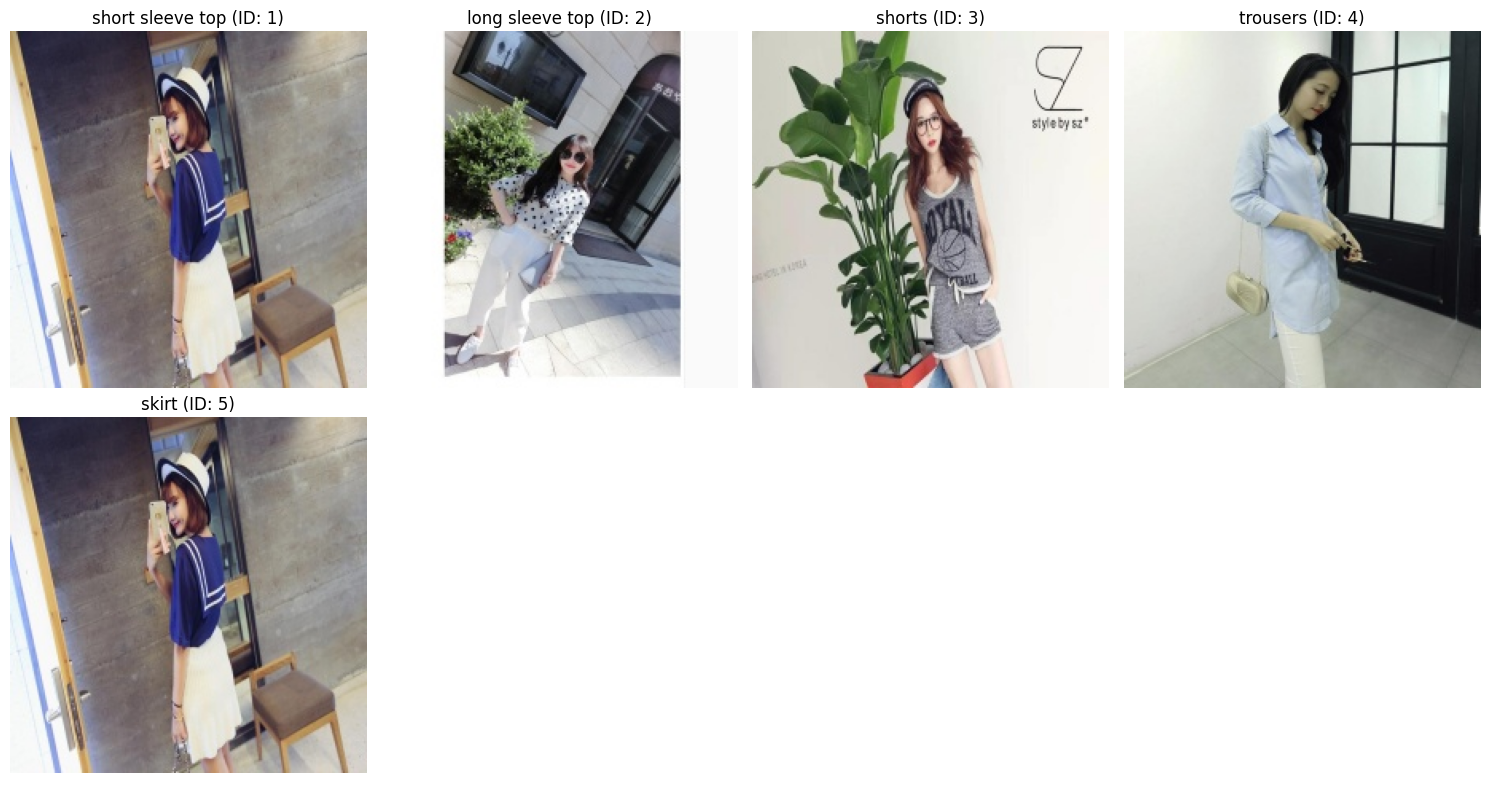

In [38]:
import math

n_images = NUM_CLASSES
cols = 4
rows = math.ceil(n_images / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 4*rows))
axes = axes.flatten()

for idx, (cat_id, cat_name) in enumerate(id_to_category.items()):
    sample = train_df[train_df["category_id"] == cat_id].iloc[0]
    img = cv2.imread(sample['path'])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Get bounding box coordinates
    # bbox = sample['b_box']
    # x1, y1, x2, y2 = [int(coord) for coord in bbox]

    # Draw bounding box
    # cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2) # Red rectangle with thickness 2

    axes[idx].imshow(img)
    axes[idx].set_title(f"{cat_name} (ID: {cat_id})")
    axes[idx].axis("off")

for j in range(idx+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [39]:
import random
seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)
random.seed(seed)

I0000 00:00:1774064643.087370      25 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


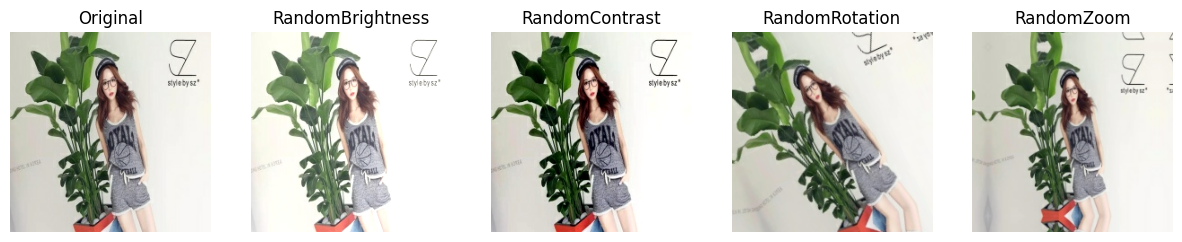

In [40]:
augmentation_layers = {
    'RandomBrightness': tf.keras.layers.RandomBrightness(0.25),
    'RandomContrast': tf.keras.layers.RandomContrast(0.25),
    'RandomRotation': tf.keras.layers.RandomRotation(0.1),
    'RandomZoom': tf.keras.layers.RandomZoom(0.3),
}

# Pick a sample image (e.g., trousers)
sample_path = train_df.iloc[1]['path']
img_raw = tf.io.read_file(sample_path)
img_tensor = tf.image.decode_jpeg(img_raw, channels=3)
img_tensor = tf.image.resize(img_tensor, (IMG_SIZE, IMG_SIZE))
img_batch = tf.expand_dims(img_tensor, 0)

plt.figure(figsize=(15, 4))
plt.subplot(1, 5, 1)
plt.imshow(img_tensor.numpy().astype(np.uint8))
plt.title("Original")
plt.axis("off")

for i, (name, layer) in enumerate(augmentation_layers.items()):
    aug_img = layer(img_batch, training=True)
    plt.subplot(1, 5, i+2)
    plt.imshow(tf.clip_by_value(aug_img[0], 0, 255).numpy().astype(np.uint8))
    plt.title(name)
    plt.axis("off")
plt.show()

In [41]:
from tensorflow.keras.applications.resnet50 import preprocess_input

from sklearn.model_selection import train_test_split

unique_paths = train_df['path'].unique()
train_paths, test_paths = train_test_split(unique_paths, test_size=0.1, random_state=42, shuffle=True)
train_split_df = train_df[train_df['path'].isin(train_paths)].reset_index(drop=True)
test_df        = train_df[train_df['path'].isin(test_paths)].reset_index(drop=True)

# Step 2: Convert ALL splits to multi-label pivot format ONCE, outside create_tf_dataset
CATEGORY_IDS = sorted(train_df['category_id'].unique())   # e.g. [1, 2, 3, 4, 5]

def to_multilabel_df(df, category_ids):
    """Long-format (one row/annotation) → wide multi-hot (one row/image)."""
    ml_df = (
        df.assign(value=1)
          .pivot_table(index='path', columns='category_id',
                       values='value', fill_value=0)
          .reset_index()
    )
    # Guarantee every class column exists and is in fixed order
    ml_df = ml_df.reindex(columns=['path'] + list(category_ids), fill_value=0)
    return ml_df

train_ml_df = to_multilabel_df(train_split_df, CATEGORY_IDS)
val_ml_df   = to_multilabel_df(validation_df,  CATEGORY_IDS)
test_ml_df  = to_multilabel_df(test_df,        CATEGORY_IDS)

print("train:", train_ml_df.shape,
      "| val:", val_ml_df.shape,
      "| test:", test_ml_df.shape)
print(train_ml_df.head())

def create_tf_dataset(ml_df, batch_size=32, shuffle=False, augment=False):
    """
    ml_df: already-pivoted DataFrame with columns ['path', cat_id1, cat_id2, ...]
    """
    label_columns = ml_df.columns[1:]   # all columns after 'path'
    paths  = ml_df['path'].values
    labels = ml_df[label_columns].values.astype(np.float32)

    def parse_image(path, label):
        image = tf.io.read_file(path)
        image = tf.image.decode_jpeg(image, channels=3)
        image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
        image = preprocess_input(image)
        return image, tf.cast(label, tf.float32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(len(ml_df), reshuffle_each_iteration=True)
    ds = ds.map(parse_image, num_parallel_calls=tf.data.AUTOTUNE)

    if augment:
        aug_model = tf.keras.Sequential([
            tf.keras.layers.RandomBrightness(0.1),
            tf.keras.layers.RandomContrast(0.1),
            tf.keras.layers.RandomRotation(0.1),
            tf.keras.layers.RandomZoom(0.1),
        ])
        ds = ds.map(lambda x, y: (aug_model(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)

    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_tfds = create_tf_dataset(train_ml_df, shuffle=True, augment=True)
val_tfds   = create_tf_dataset(val_ml_df)
test_tfds  = create_tf_dataset(test_ml_df)

train: (129756, 6) | val: (23741, 6) | test: (14418, 6)
category_id                                   path    1    2    3    4    5
0            /kaggle/temp/resized/train/000001.jpg  1.0  0.0  0.0  1.0  0.0
1            /kaggle/temp/resized/train/000002.jpg  1.0  0.0  0.0  0.0  0.0
2            /kaggle/temp/resized/train/000009.jpg  0.0  1.0  0.0  0.0  0.0
3            /kaggle/temp/resized/train/000010.jpg  0.0  1.0  0.0  0.0  0.0
4            /kaggle/temp/resized/train/000011.jpg  0.0  1.0  0.0  1.0  0.0


In [42]:
# train_tdfs.head()

In [43]:
# validation_tdfs.head()

In [44]:
# test_tdfs.head()

In [45]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(train_split_df['category_id'])
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_split_df['category_id']
)

class_weight_dict = dict(zip(classes, class_weights))
print(class_weight_dict)

{np.int64(1): np.float64(0.6438782951389428), np.int64(2): np.float64(1.2768407125934587), np.int64(3): np.float64(1.2582577847851792), np.int64(4): np.float64(0.8323859191655801), np.int64(5): np.float64(1.4978740299584912)}


In [46]:
RESNET50_TRAIN = False
EFFICIENT_TRAIN = False
MOBILENET_TRAIN=True

In [47]:
import tensorflow.keras.metrics;
## TRAINING FROM SCRATCH!!!

scratch_base = tf.keras.applications.ResNet50(
    weights=None,
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

scratch_inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = scratch_base(scratch_inputs)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)
scratch_outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='sigmoid')(x)

scratch_model = tf.keras.Model(scratch_inputs, scratch_outputs)
scratch_model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss='binary_crossentropy', metrics=[tf.keras.metrics.BinaryAccuracy(name='binary_accuracy'),
                          tf.keras.metrics.AUC(name='auc', multi_label=True)])
scratch_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,121,733 (92.02 MB)

 Trainable params: 24,064,517 (91.80 MB)

 Non-trainable params: 57,216 (223.50 KB)

In [48]:
EPOCHS = 20
if RESNET50_TRAIN:
    history_scratch = scratch_model.fit(train_tfds, validation_data=val_tfds, epochs=EPOCHS,verbose=2)

In [49]:
from sklearn.metrics import f1_score
def evaluate_model(trained_model, tf_dataset, id_to_cat, title="Model"):
    results = trained_model.evaluate(tf_dataset, verbose=0,return_dict=True)

    print(f"\n{'='*50}\n  {title}\n{'='*50}")
    for name, value in results.items():
        print(f"  {name:<18}: {value:.4f}")

    # Collect predictions — keep multi-hot format throughout
    y_true_list, y_pred_probs_list = [], []
    for imgs, lbls in tf_dataset:
        y_true_list.extend(lbls.numpy())
        probs = trained_model.predict(imgs, verbose=0)
        y_pred_probs_list.extend(probs)

    y_true = np.array(y_true_list)           # shape: (N, num_classes), already binary
    y_pred_probs = np.array(y_pred_probs_list)
    y_pred = (y_pred_probs >= 0.5).astype(int)  # ✅ threshold, not argmax

    target_names = [id_to_cat[i+1] for i in range(len(id_to_cat))]
    n_cls = len(target_names)

    # Per-class + macro + micro F1
    print("--- Per-class Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=target_names, digits=4))

    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    micro_f1 = f1_score(y_true, y_pred, average='micro', zero_division=0)
    print(f"  Macro F1 : {macro_f1:.4f}")
    print(f"  Micro F1 : {micro_f1:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ROC curve — y_true is already binary, no label_binarize needed
    for i in range(n_cls):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_pred_probs[:, i])
        auc_val = roc_auc_score(y_true[:, i], y_pred_probs[:, i])
        axes[0].plot(fpr, tpr, label=f"{target_names[i]} (AUC={auc_val:.4f})")
    axes[0].plot([0,1],[0,1],'k--')
    axes[0].set(xlabel="FPR", ylabel="TPR", title=f"{title} – ROC Curve")
    axes[0].legend(fontsize=8); axes[0].grid(True)

    # ✅ Remove multi_class="ovr" — it is for single-label only
    macro_auc = roc_auc_score(y_true, y_pred_probs, average="macro")
    micro_auc = roc_auc_score(y_true, y_pred_probs, average="micro")
    print(f"  Macro ROC AUC : {macro_auc:.4f}")
    print(f"  Micro ROC AUC : {micro_auc:.4f}")

    # Precision-Recall curve
    for i in range(n_cls):
        prec, rec, _ = precision_recall_curve(y_true[:, i], y_pred_probs[:, i])
        ap = average_precision_score(y_true[:, i], y_pred_probs[:, i])
        axes[1].plot(rec, prec, label=f"{target_names[i]} (AP={ap:.4f})")
    axes[1].set(xlabel="Recall", ylabel="Precision", title=f"{title} – PR Curve")
    axes[1].legend(fontsize=8); axes[1].grid(True)

    plt.tight_layout(); plt.show()
    return y_true, y_pred, y_pred_probs


In [50]:
print(id_to_category)

{1: 'short sleeve top', 2: 'long sleeve top', 3: 'shorts', 4: 'trousers', 5: 'skirt'}


In [51]:
if RESNET50_TRAIN:
    a,b,c = evaluate_model(scratch_model,test_tfds,id_to_category,"Trained From Scratch")

In [52]:
if RESNET50_TRAIN:
    scratch_model.save("resnet50_scratch.keras")

In [53]:
## TRANSFER LEARNING!!

base_model = tf.keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False # Freeze weights

tl_inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(tl_inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)
tl_outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='sigmoid')(x)

tl_model = tf.keras.Model(tl_inputs, tl_outputs)
tl_model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss='binary_crossentropy', metrics=[tf.keras.metrics.BinaryAccuracy(name='binary_accuracy'),
                          tf.keras.metrics.AUC(name='auc', multi_label=True)])

tl_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,121,733 (92.02 MB)

 Trainable params: 529,925 (2.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [54]:
EPOCHS = 20
if RESNET50_TRAIN:
    history_tl = tl_model.fit(train_tfds, validation_data=val_tfds, epochs=EPOCHS)

In [55]:
if RESNET50_TRAIN:
    tl_model.save('resnet50_TL.keras')

In [56]:
if RESNET50_TRAIN:
    a,b,c =  evaluate_model(tl_model,test_tfds,id_to_category,"Trained From Transfer Learning")

In [57]:
# print(a,b,c)

In [58]:
# # ✅ Build grad_model from tl_model's input → (last conv output, final sigmoid output)
# last_conv_layer_name = "conv5_block3_3_conv"

# grad_model = tf.keras.models.Model(
#     inputs=tl_model.input,
#     outputs=[
#         tl_model.get_layer('resnet50').get_layer(last_conv_layer_name).output,
#         tl_model.output   # shape: (batch, 5) — sigmoid probabilities
#     ]
# )

# def get_gradcam_multilabel(img_tensor, threshold=0.5):
#     with tf.GradientTape() as tape:
#         conv_outputs, predictions = grad_model(img_tensor)
#         tape.watch(conv_outputs)
#         # ✅ Sum losses for ALL positively predicted classes (multi-label)
#         active_mask = tf.cast(predictions[0] > threshold, tf.float32)
#         loss = tf.reduce_sum(predictions[0] * active_mask)

#     grads = tape.gradient(loss, conv_outputs)
#     pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
#     heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
#     heatmap = tf.squeeze(heatmap)
#     heatmap = tf.nn.relu(heatmap) / (tf.reduce_max(heatmap) + 1e-8)
#     return heatmap.numpy()

# # Usage
# img_batch, lbl_batch = next(iter(test_tfds))
# img = img_batch[0:1]
# heatmap = get_gradcam_multilabel(img)

In [59]:
# ─── EfficientNetB0 Training From Scratch───
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess

eff_base = EfficientNetB0(weights=None, include_top=False,
                          input_shape=(IMG_SIZE, IMG_SIZE, 3))
eff_base.trainable = True

eff_inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = eff_base(eff_inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)
eff_outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='sigmoid')(x)

eff_model_scratch = tf.keras.Model(eff_inputs, eff_outputs)
eff_model_scratch.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                  loss='binary_crossentropy',
                  metrics=[tf.keras.metrics.BinaryAccuracy(name='binary_accuracy'),
                            tf.keras.metrics.AUC(name='auc', multi_label=True)])

In [60]:
EPOCHS = 20
if EFFICIENT_TRAIN:
    eff_history = eff_model_scratch.fit(train_tfds, validation_data=val_tfds, epochs=EPOCHS)

In [61]:
if EFFICIENT_TRAIN:
    eff_model_scratch.save('eff_scratch.keras')

In [62]:
if EFFICIENT_TRAIN:
    a,b,c =  evaluate_model(eff_model_scratch,test_tfds,id_to_category,"Trained From Transfer Learning")

In [63]:
# ─── EfficientNetB0 Transfer Learning ───
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess

eff_base = EfficientNetB0(weights='imagenet', include_top=False,
                          input_shape=(IMG_SIZE, IMG_SIZE, 3))
eff_base.trainable = False

eff_inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = eff_base(eff_inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)
eff_outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='sigmoid')(x)

eff_model_tl = tf.keras.Model(eff_inputs, eff_outputs)
eff_model_tl.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                  loss='binary_crossentropy',
                  metrics=[tf.keras.metrics.BinaryAccuracy(name='binary_accuracy'),
                            tf.keras.metrics.AUC(name='auc', multi_label=True)])

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [64]:
EPOCHS = 20
if EFFICIENT_TRAIN:
    eff_tl_history = eff_model_tl.fit(train_tfds, validation_data=val_tfds, epochs=EPOCHS)

In [65]:
if EFFICIENT_TRAIN:
    eff_model_tl.save('eff_tl.keras')

In [66]:
if EFFICIENT_TRAIN:
    a,b,c =  evaluate_model(eff_model_tl,test_tfds,id_to_category,"Trained From Transfer Learning")

In [67]:
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as mob_preprocess

mob_base = MobileNetV3Large(weights=None, include_top=False,
                             input_shape=(IMG_SIZE, IMG_SIZE, 3))
mob_base.trainable = True

mob_inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = mob_base(mob_inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)
mob_outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='sigmoid')(x)

mob_model_scratch = tf.keras.Model(mob_inputs, mob_outputs)
mob_model_scratch.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                  loss='binary_crossentropy',
                  metrics=[tf.keras.metrics.BinaryAccuracy(name='binary_accuracy'),
                            tf.keras.metrics.AUC(name='auc', multi_label=True)])

In [68]:
EPOCHS = 20
if MOBILENET_TRAIN:
    mob_history = mob_model_scratch.fit(train_tfds, validation_data=val_tfds, epochs=EPOCHS)

Epoch 1/20


I0000 00:00:1774064684.544837      79 service.cc:152] XLA service 0x7ae5280026e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774064684.544884      79 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1774064689.429156      79 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-21 03:44:59.006661: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-21 03:44:59.190595: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-21 03:44:59.621994: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accur

4054/4055 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - auc: 0.5290 - binary_accuracy: 0.6722 - loss: 0.6302

2026-03-21 03:57:49.569231: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-21 03:57:49.753670: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-21 03:57:50.182588: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-21 03:57:50.381677: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


4055/4055 ━━━━━━━━━━━━━━━━━━━━ 860s 198ms/step - auc: 0.5290 - binary_accuracy: 0.6723 - loss: 0.6302 - val_auc: 0.5084 - val_binary_accuracy: 0.6848 - val_loss: 0.5982
Epoch 2/20
4055/4055 ━━━━━━━━━━━━━━━━━━━━ 760s 187ms/step - auc: 0.6428 - binary_accuracy: 0.7169 - loss: 0.5634 - val_auc: 0.5897 - val_binary_accuracy: 0.6901 - val_loss: 0.6814
Epoch 3/20
4055/4055 ━━━━━━━━━━━━━━━━━━━━ 765s 188ms/step - auc: 0.7078 - binary_accuracy: 0.7395 - loss: 0.5262 - val_auc: 0.6166 - val_binary_accuracy: 0.6796 - val_loss: 0.7324
Epoch 4/20
4055/4055 ━━━━━━━━━━━━━━━━━━━━ 768s 189ms/step - auc: 0.7406 - binary_accuracy: 0.7512 - loss: 0.5063 - val_auc: 0.6134 - val_binary_accuracy: 0.7078 - val_loss: 0.6725
Epoch 5/20
4055/4055 ━━━━━━━━━━━━━━━━━━━━ 766s 189ms/step - auc: 0.7662 - binary_accuracy: 0.7649 - loss: 0.4858 - val_auc: 0.6640 - val_binary_accuracy: 0.7011 - val_loss: 0.7336
Epoch 6/20
4055/4055 ━━━━━━━━━━━━━━━━━━━━ 768s 189ms/step - auc: 0.7878 - binary_accuracy: 0.7755 - loss: 0.468

In [69]:
if MOBILENET_TRAIN:
    mob_model_scratch.save('mob_scratch.keras')


  Trained From Transfer Learning
  auc               : 0.8004
  binary_accuracy   : 0.7786
  loss              : 0.4864
--- Per-class Classification Report ---
                  precision    recall  f1-score   support

short sleeve top     0.6866    0.6598    0.6729      7086
 long sleeve top     0.6265    0.2732    0.3805      3536
          shorts     0.8025    0.4625    0.5868      3611
        trousers     0.7626    0.6868    0.7227      5492
           skirt     0.5216    0.3341    0.4073      3113

       micro avg     0.6978    0.5308    0.6030     22838
       macro avg     0.6800    0.4833    0.5540     22838
    weighted avg     0.6914    0.5308    0.5898     22838
     samples avg     0.6050    0.5310    0.5466     22838

  Macro F1 : 0.5540
  Micro F1 : 0.6030
  Macro ROC AUC : 0.8006
  Micro ROC AUC : 0.8219


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


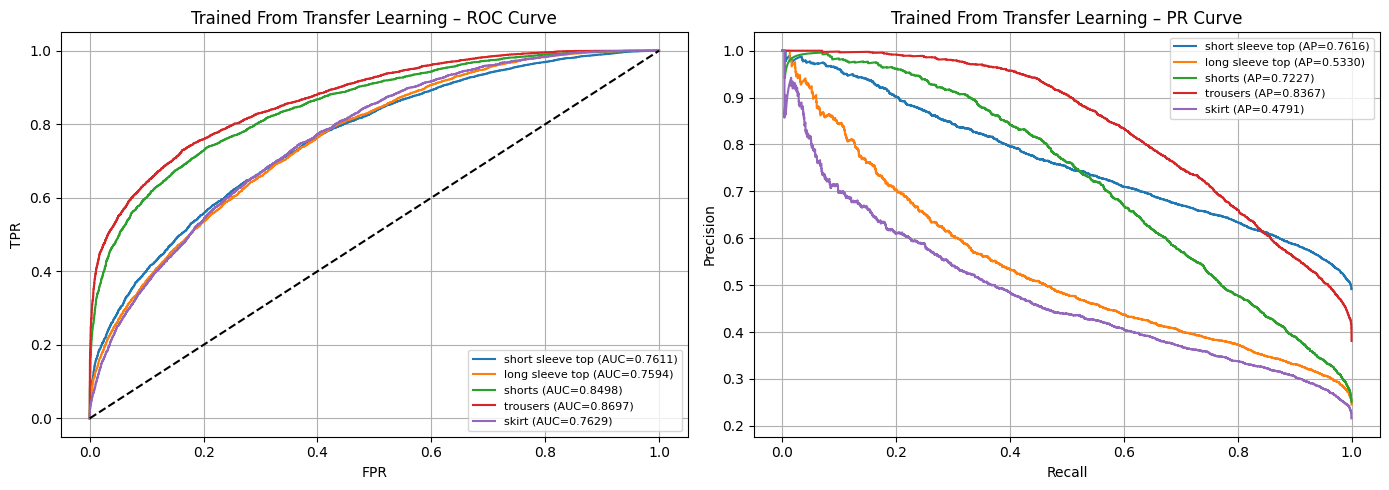

In [70]:
if MOBILENET_TRAIN:
    a,b,c =  evaluate_model(mob_model_scratch,test_tfds,id_to_category,"Trained From Transfer Learning")

In [71]:
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as mob_preprocess

mob_base = MobileNetV3Large(weights='imagenet', include_top=False,
                             input_shape=(IMG_SIZE, IMG_SIZE, 3))
mob_base.trainable = False

mob_inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = mob_base(mob_inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)
mob_outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='sigmoid')(x)

mob_model_tl = tf.keras.Model(mob_inputs, mob_outputs)
mob_model_tl.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                  loss='binary_crossentropy',
                  metrics=[tf.keras.metrics.BinaryAccuracy(name='binary_accuracy'),
                            tf.keras.metrics.AUC(name='auc', multi_label=True)])

12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [72]:
EPOCHS = 20
if MOBILENET_TRAIN:
    mob_tl_history = mob_model_tl.fit(train_tfds, validation_data=val_tfds, epochs=EPOCHS)

Epoch 1/20
4055/4055 ━━━━━━━━━━━━━━━━━━━━ 633s 153ms/step - auc: 0.6227 - binary_accuracy: 0.6685 - loss: 0.6649 - val_auc: 0.7477 - val_binary_accuracy: 0.7368 - val_loss: 0.5504
Epoch 2/20
4055/4055 ━━━━━━━━━━━━━━━━━━━━ 606s 149ms/step - auc: 0.7278 - binary_accuracy: 0.7401 - loss: 0.5264 - val_auc: 0.7614 - val_binary_accuracy: 0.7440 - val_loss: 0.5239
Epoch 3/20
4055/4055 ━━━━━━━━━━━━━━━━━━━━ 608s 150ms/step - auc: 0.7542 - binary_accuracy: 0.7533 - loss: 0.5042 - val_auc: 0.7663 - val_binary_accuracy: 0.7465 - val_loss: 0.5199
Epoch 4/20
4055/4055 ━━━━━━━━━━━━━━━━━━━━ 604s 149ms/step - auc: 0.7639 - binary_accuracy: 0.7588 - loss: 0.4959 - val_auc: 0.7732 - val_binary_accuracy: 0.7508 - val_loss: 0.5124
Epoch 5/20
4055/4055 ━━━━━━━━━━━━━━━━━━━━ 623s 154ms/step - auc: 0.7742 - binary_accuracy: 0.7634 - loss: 0.4878 - val_auc: 0.7740 - val_binary_accuracy: 0.7529 - val_loss: 0.5126
Epoch 6/20
4055/4055 ━━━━━━━━━━━━━━━━━━━━ 656s 162ms/step - auc: 0.7809 - binary_accuracy: 0.7673 - 


  Trained From Transfer Learning
  auc               : 0.8057
  binary_accuracy   : 0.7705
  loss              : 0.4799
--- Per-class Classification Report ---
                  precision    recall  f1-score   support

short sleeve top     0.7567    0.4445    0.5600      7086
 long sleeve top     0.5870    0.3416    0.4319      3536
          shorts     0.8182    0.2791    0.4163      3611
        trousers     0.7275    0.7511    0.7391      5492
           skirt     0.6831    0.2583    0.3748      3113

       micro avg     0.7199    0.4508    0.5544     22838
       macro avg     0.7145    0.4149    0.5044     22838
    weighted avg     0.7231    0.4508    0.5353     22838
     samples avg     0.5739    0.4662    0.4964     22838

  Macro F1 : 0.5044
  Micro F1 : 0.5544
  Macro ROC AUC : 0.8059
  Micro ROC AUC : 0.8183


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


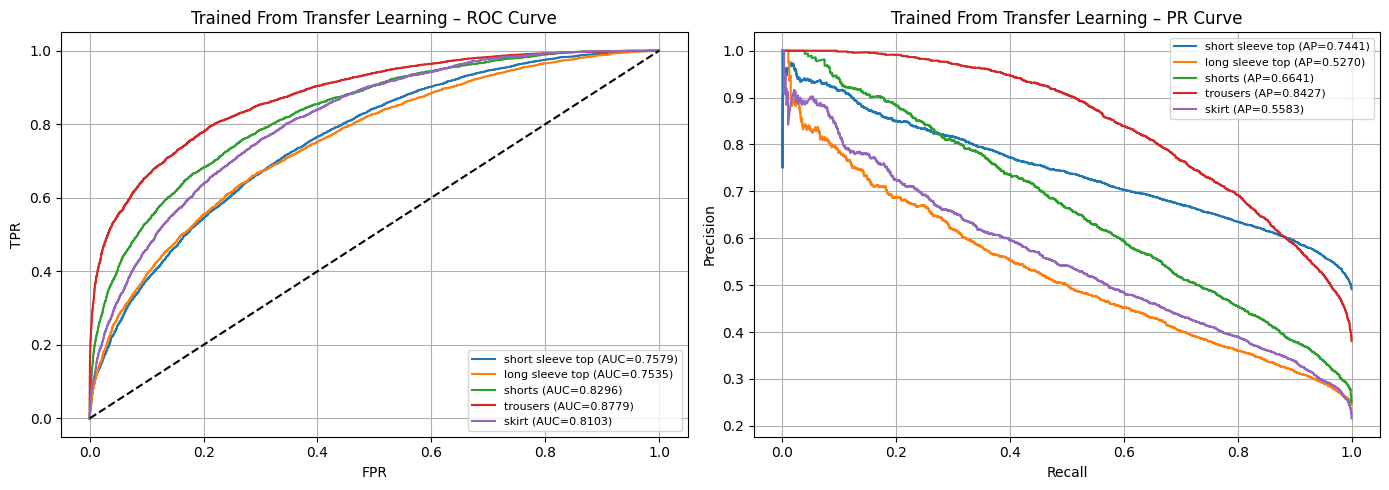

In [73]:
if MOBILENET_TRAIN:
    a,b,c =  evaluate_model(mob_model_tl,test_tfds,id_to_category,"Trained From Transfer Learning")

In [74]:
if MOBILENET_TRAIN:
    mob_model_tl.save('mob_scratch.keras')